In [1]:
from google.colab import files
uploaded = files.upload()

Saving synthetic_heart_disease_dataset.csv to synthetic_heart_disease_dataset.csv


In [69]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [70]:
dataset = pd.read_csv('synthetic_heart_disease_dataset.csv')

In [71]:
print(dataset.isnull().sum())
dataset['Alcohol_Intake'] = dataset['Alcohol_Intake'].fillna('Unknown')

X = dataset.iloc[ : , :-1].values
y = dataset.iloc[ : , -1].values

Age                          0
Gender                       0
Weight                       0
Height                       0
BMI                          0
Smoking                      0
Alcohol_Intake           20109
Physical_Activity            0
Diet                         0
Stress_Level                 0
Hypertension                 0
Diabetes                     0
Hyperlipidemia               0
Family_History               0
Previous_Heart_Attack        0
Systolic_BP                  0
Diastolic_BP                 0
Heart_Rate                   0
Blood_Sugar_Fasting          0
Cholesterol_Total            0
Heart_Disease                0
dtype: int64


In [72]:
print(dataset.shape)
print(dataset.describe())
dataset.info()

(50000, 21)
               Age        Weight        Height           BMI  Hypertension  \
count  50000.00000  50000.000000  50000.000000  50000.000000  50000.000000   
mean      54.46406     84.547520    174.460000     28.984284      0.299620   
std       14.43809     20.213257     14.420379      6.367494      0.458096   
min       30.00000     50.000000    150.000000     18.000000      0.000000   
25%       42.00000     67.000000    162.000000     23.500000      0.000000   
50%       54.00000     85.000000    174.000000     29.000000      0.000000   
75%       67.00000    102.000000    187.000000     34.500000      1.000000   
max       79.00000    119.000000    199.000000     40.000000      1.000000   

           Diabetes  Hyperlipidemia  Family_History  Previous_Heart_Attack  \
count  50000.000000    50000.000000    50000.000000           50000.000000   
mean       0.199260        0.251660        0.400500               0.099280   
std        0.399448        0.433971        0.490005

In [73]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(), [1,5,6,7,8,9])],
    remainder='passthrough'
)
X = np.array(ct.fit_transform(X))

In [87]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state = 42)

In [86]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [88]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [77]:
y_pred = model.predict(X_test)
print(y_pred)

[1 0 0 ... 0 0 1]


In [90]:
print("Accuracy",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report: \n", classification_report(y_test,y_pred))

Accuracy 0.9252666666666667
Confusion Matrix:
 [[7447  531]
 [ 590 6432]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      7978
           1       0.92      0.92      0.92      7022

    accuracy                           0.93     15000
   macro avg       0.93      0.92      0.92     15000
weighted avg       0.93      0.93      0.93     15000



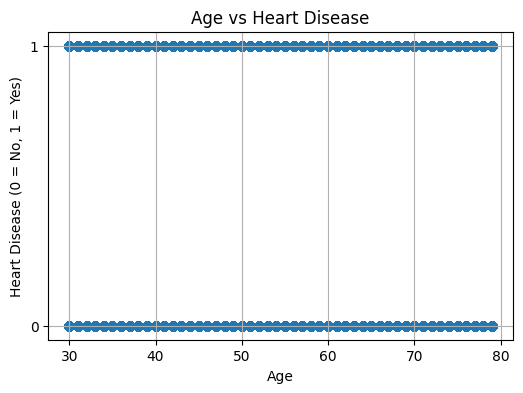

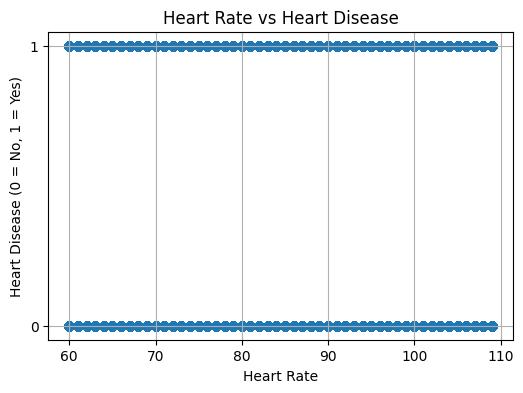

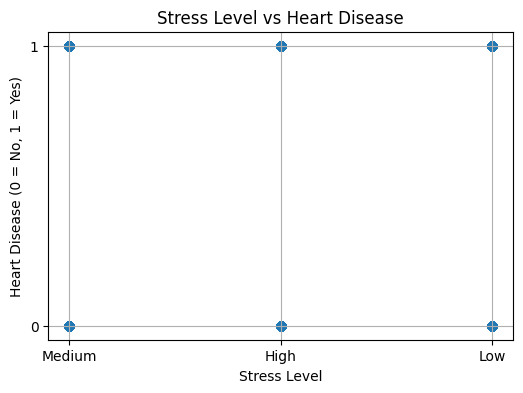

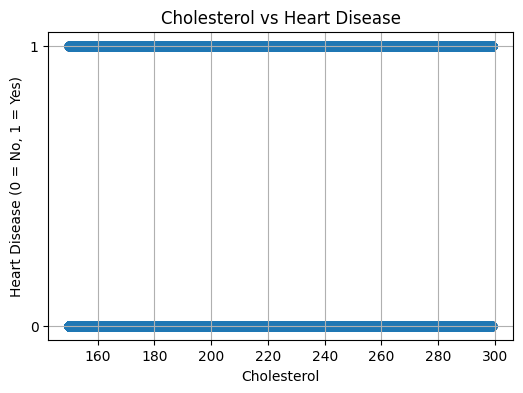

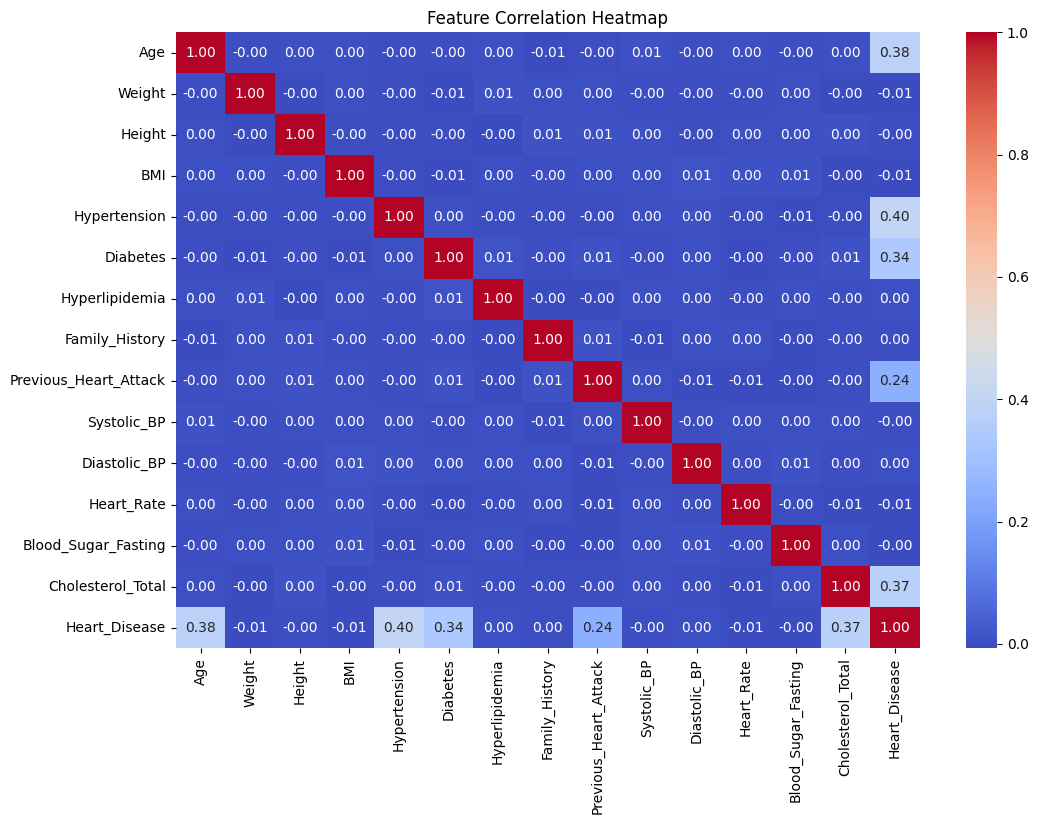

In [79]:
plt.figure(figsize=(6,4))
plt.scatter(dataset["Age"], dataset["Heart_Disease"], alpha=0.4)
plt.title("Age vs Heart Disease")
plt.xlabel("Age")
plt.ylabel("Heart Disease (0 = No, 1 = Yes)")
plt.yticks([0,1])
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(dataset["Heart_Rate"], dataset["Heart_Disease"], alpha=0.4)
plt.title("Heart Rate vs Heart Disease")
plt.xlabel("Heart Rate")
plt.ylabel("Heart Disease (0 = No, 1 = Yes)")
plt.yticks([0,1])
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(dataset["Stress_Level"], dataset["Heart_Disease"], alpha=0.4)
plt.title("Stress Level vs Heart Disease")
plt.xlabel("Stress Level")
plt.ylabel("Heart Disease (0 = No, 1 = Yes)")
plt.yticks([0,1])
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(dataset["Cholesterol_Total"], dataset["Heart_Disease"], alpha=0.4)
plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Cholesterol")
plt.ylabel("Heart Disease (0 = No, 1 = Yes)")
plt.yticks([0,1])
plt.grid(True)
plt.show()


# Correlation Heatmap

plt.figure(figsize=(12,8))
sn.heatmap(dataset.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()
